In [33]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [34]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [35]:
benchmark = ffmpeg

In [36]:
generate_static_info(benchmark.binary)

In [37]:
static_info = get_static_info(benchmark.binary)
static_info

,id,name,size.bytecode,size.static
0,24,__wasm_call_ctors,8,864
1,25,undefined_weak:__wasilibc_find_relpath_alloc,4,504
2,26,_start,69,984
3,27,__SIG_IGN,3,512
4,28,__SIG_ERR,5,504
...,...,...,...,...
27485,27509,ff_tx_fft16_ns_int32_c,2188,3344
27486,27510,ff_tx_fft8_ns_int32_c,1144,2096
27487,27511,ff_tx_fft4_ns_int32_c,382,912
27488,27512,ff_tx_fft2_ns_int32_c,163,664


In [38]:
for wl in benchmark.workloads:
    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / 'profile.csv')
    print(base_profile.head())

     id                          name  size.bytecode  size.static  start.jit  \
0    26                        _start             69          984      70848   
1    24             __wasm_call_ctors              8          864    3747522   
2    30                          init             20          840    5571401   
3  1540         __wasi_clock_time_get             20          824    7550469   
4  1588  __wasilibc_populate_preopens            182         1296    9513100   

   exec.jit  freq.jit  compilation.jit  size.dynamic.jit  start.interp  \
0         0         0          3675552               984         72965   
1         0         1          1823296               864         77094   
2         0         1          1978378               840         77805   
3         0       109          1956529               824         79312   
4         0         1          5488068              1296         87298   

   exec.interp  freq.interp     exec.spec  compilation.spec  size.dynamic.

## Interpretation cost estimation

Goal: given the **static info** (`size.bytecode`, `size.static`) and a function's **JIT execution time** (`exec.jit`, `freq.jit`), predict its interpretation cost (`exec.interp`) — without running the interpreter.

In [39]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

OUT = Path('out')
OUT.mkdir(exist_ok=True)
print("Setup complete.")

Setup complete.


### 1. Load profiling data

In [40]:
# ── features used by the model ────────────────────────────────────────────────
_FEATURES = ['exec.jit', 'freq.jit', 'size.bytecode', 'size.static']

_all_dfs = []
for _i, _wl in enumerate(benchmark.workloads):
    _path = profiles_root(benchmark.binary, _wl.name) / 'profile.csv'
    if not _path.exists():
        continue
    _df = pd.read_csv(_path)
    _df['workload'] = _wl.name
    _df['wl_idx']   = _i
    _all_dfs.append(_df)

raw = pd.concat(_all_dfs).reset_index(drop=True)

# keep functions observed in both JIT and interp modes with valid timings
data = raw[
    (raw['freq.jit']    > 0) &
    (raw['exec.jit']    > 0) &
    (raw['exec.interp'] > 0) &
    (raw['exec.interp'] < 9e11)
].copy().reset_index(drop=True)

# per-call exec time (removes trivial call-count scaling for plots)
data['t_jit']    = data['exec.jit']    / data['freq.jit']
data['t_interp'] = data['exec.interp'] / data['freq.interp'].clip(lower=1)
data['ratio']    = data['exec.interp'] / data['exec.jit']

workload_names = sorted(data['workload'].unique().tolist())
print(f"{len(data)} (function, workload) pairs  \u00b7  "
      f"{data['id'].nunique()} unique functions  \u00b7  "
      f"{len(workload_names)} workloads")
data[['exec.jit', 'exec.interp', 'ratio', 'size.bytecode', 'size.static']].describe(
    percentiles=[.05, .25, .5, .75, .95])

2594 (function, workload) pairs  ·  503 unique functions  ·  16 workloads


,exec.jit,exec.interp,ratio,size.bytecode,size.static
count,2.594000e+03,2.594000e+03,2594.000000,2594.000000,2594.000000
mean,8.431380e+07,2.190575e+10,215.869584,6801.455281,4890.852737
std,3.584860e+08,7.868356e+10,492.292859,21068.517105,13168.403605
min,1.000000e+06,1.000000e+06,0.500000,9.000000,520.000000
5%,1.000000e+06,3.000000e+06,2.000000,89.000000,616.000000
25%,1.000000e+06,7.800000e+07,28.687963,285.250000,984.000000
50%,1.000000e+07,1.215000e+09,91.546032,777.000000,1336.000000
75%,5.700000e+07,8.185000e+09,252.416667,2798.000000,2264.000000
95%,2.910000e+08,1.022476e+11,712.773256,29825.000000,18080.000000
max,1.021100e+10,8.750910e+11,12718.000000,207815.000000,123800.000000


### 2. Characterise the JIT / interpretation relationship

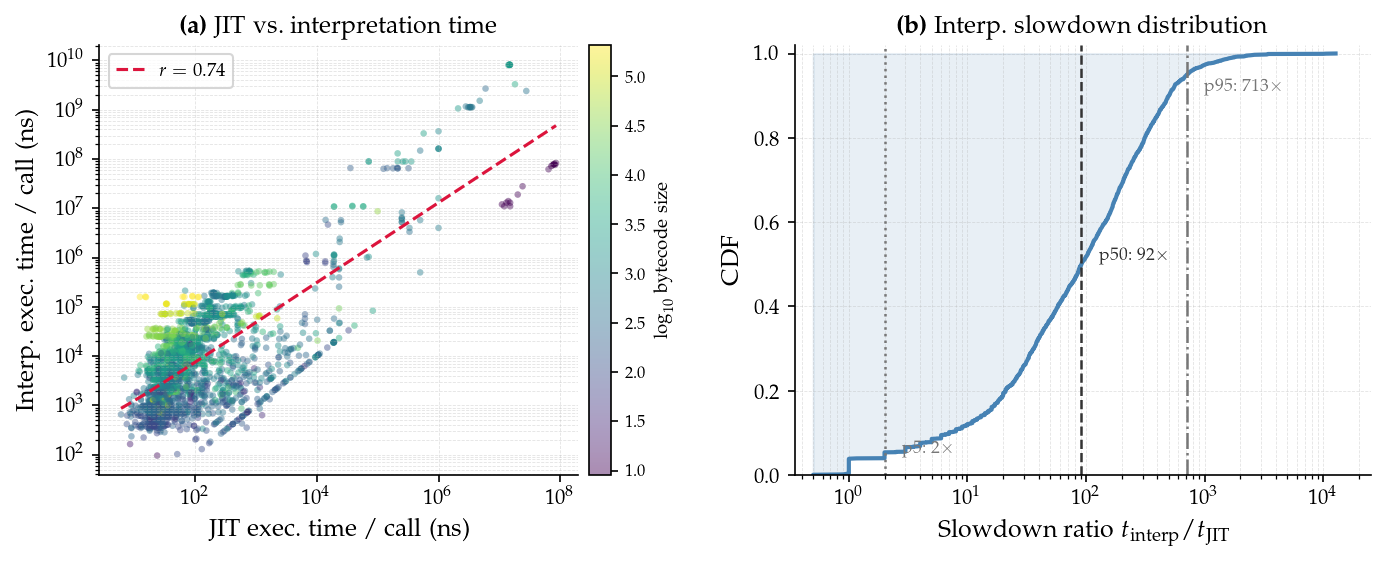

In [41]:
# Figure 1 – characterising the JIT / interpretation relationship
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

# ── (a) per-call execution-time scatter, coloured by bytecode size ─────────
ax = axes[0]
c_vals = np.log10(data['size.bytecode'].clip(lower=1))
sc = ax.scatter(
    data['t_jit'].clip(lower=1), data['t_interp'].clip(lower=1),
    c=c_vals, cmap='viridis', alpha=0.45, s=10, linewidths=0,
    vmin=c_vals.min(), vmax=c_vals.max())
cb = plt.colorbar(sc, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}$ bytecode size', fontsize=9)
cb.ax.tick_params(labelsize=8)

# OLS regression line in log space
lx = np.log1p(data['t_jit'])
ly = np.log1p(data['t_interp'])
m, b = np.polyfit(lx, ly, 1)
r, _ = pearsonr(lx, ly)
x_rng = np.logspace(
    np.log10(data['t_jit'].clip(lower=1).min()),
    np.log10(data['t_jit'].clip(lower=1).max()), 120)
ax.plot(x_rng, np.expm1(m * np.log1p(x_rng) + b),
        color='crimson', lw=1.5, ls='--', label=fr'$r = {r:.2f}$')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'JIT exec.\ time / call (ns)')
ax.set_ylabel(r'Interp.\ exec.\ time / call (ns)')
ax.set_title(r'\textbf{(a)}~JIT vs.\ interpretation time')
ax.legend(handlelength=1.5)
ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.35)

# ── (b) CDF of interp / JIT slowdown ratio ────────────────────────────────
ax = axes[1]
ratios = np.sort(data['ratio'].values)
cdf    = np.arange(1, len(ratios) + 1) / len(ratios)

ax.plot(ratios, cdf, lw=2, color='steelblue')
ax.fill_betweenx(cdf, ratios, ratios.min(), alpha=0.12, color='steelblue')

for pct, ls, col, yoff in [
        (5,  ':',  '#777', 0.04),
        (50, '--', '#333', 0.50),
        (95, '-.', '#777', 0.90)]:
    v = np.percentile(ratios, pct)
    ax.axvline(v, color=col, ls=ls, lw=1.2)
    ax.text(v * 1.4, yoff, fr'p{pct}: {v:.0f}$\times$',
            color=col, fontsize=8.5, va='bottom')

ax.set_xscale('log')
ax.set_xlabel(r'Slowdown ratio $t_\mathrm{interp} / t_\mathrm{JIT}$')
ax.set_ylabel(r'CDF')
ax.set_title(r'\textbf{(b)}~Interp.\ slowdown distribution')
ax.set_xlim(ratios.min() * 0.7, ratios.max() * 2)
ax.set_ylim(0, 1.02)
ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.35)

fig.tight_layout(pad=1.5)
fig.savefig(OUT / 'interp-characterization.pdf', bbox_inches='tight')
plt.show()

### 3. Random Forest model (leave-one-workload-out CV)

In [42]:
# ── Random Forest – leave-one-workload-out cross-validation ───────────────────
def _log_X(df): return np.log1p(df[_FEATURES].fillna(0).values)
def _log_y(df): return np.log1p(df['exec.interp'].values)

X      = _log_X(data)
y      = _log_y(data)
groups = data['wl_idx'].values

gkf      = GroupKFold(n_splits=len(workload_names))
cv_preds = np.empty_like(y)

for train_idx, test_idx in gkf.split(X, y, groups):
    _rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    _rf.fit(X[train_idx], y[train_idx])
    cv_preds[test_idx] = _rf.predict(X[test_idx])

data['exec.interp.pred'] = np.expm1(cv_preds)
data['rel_err']          = (np.abs(data['exec.interp.pred'] - data['exec.interp'])
                            / data['exec.interp'])

r2_rf  = r2_score(y, cv_preds)
med_rf = data['rel_err'].median()

# ── baseline: fixed median ratio ──────────────────────────────────────────────
med_ratio                     = data['ratio'].median()
data['exec.interp.baseline']  = data['exec.jit'] * med_ratio
data['rel_err.baseline']      = (np.abs(data['exec.interp.baseline'] - data['exec.interp'])
                                  / data['exec.interp'])
r2_base  = r2_score(y, np.log1p(data['exec.interp.baseline']))
med_base = data['rel_err.baseline'].median()

# ── log-linear regression baseline ───────────────────────────────────────────
lr_preds = np.empty_like(y)
for train_idx, test_idx in gkf.split(X, y, groups):
    _lr = LinearRegression()
    _lr.fit(X[train_idx], y[train_idx])
    lr_preds[test_idx] = _lr.predict(X[test_idx])
r2_lr  = r2_score(y, lr_preds)
med_lr = (np.abs(np.expm1(lr_preds) - data['exec.interp']) / data['exec.interp']).median()

print(f"{'Model':<26} {'R\u00b2 (log space)':>18} {'Median rel. error':>18}")
print("-" * 64)
print(f"{'Fixed-ratio (median)  ':<26} {r2_base:>18.4f} {med_base:>18.3f}")
print(f"{'Log-linear regression ':<26} {r2_lr:>18.4f} {med_lr:>18.3f}")
print(f"{'Random Forest         ':<26} {r2_rf:>18.4f} {med_rf:>18.3f}")

Model                          R² (log space)  Median rel. error
----------------------------------------------------------------
Fixed-ratio (median)                   0.7012              0.793
Log-linear regression                  0.8578              0.626
Random Forest                          0.9623              0.119


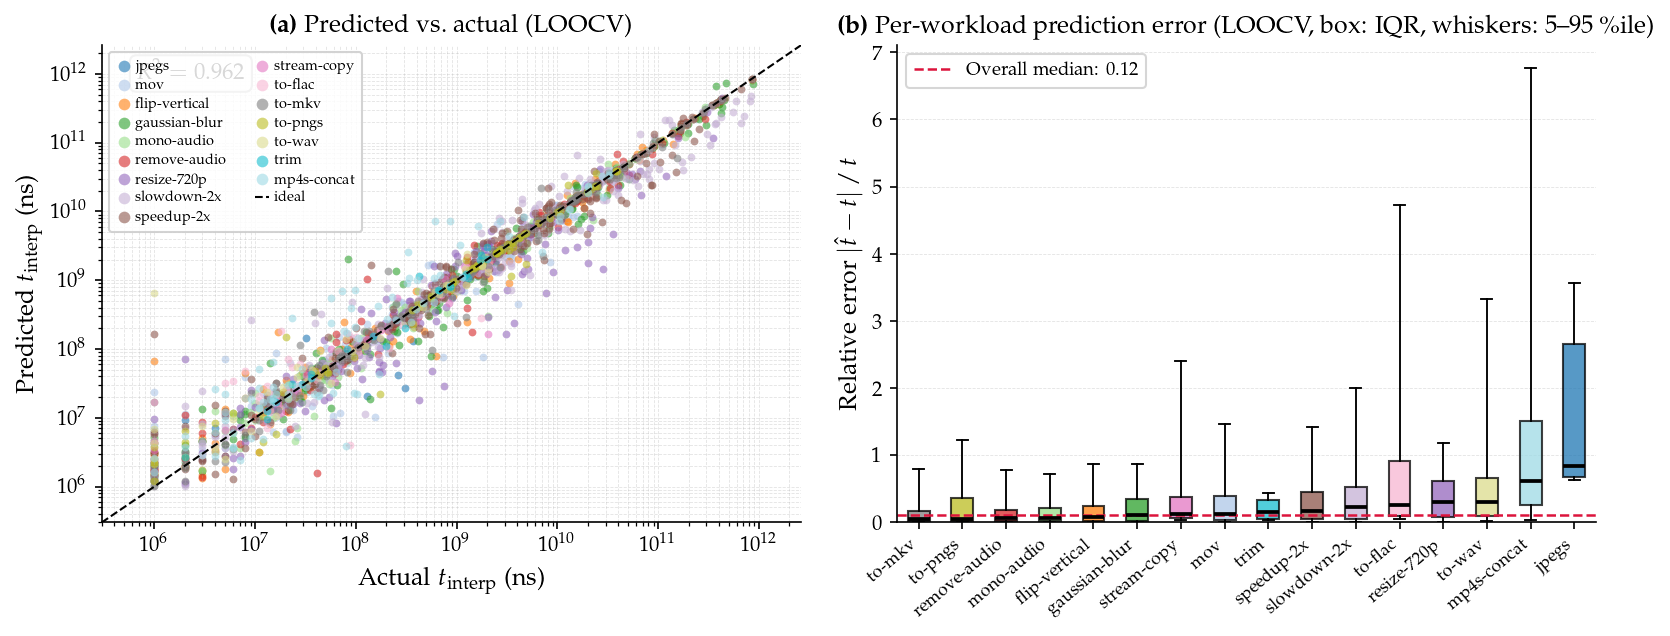

In [43]:
# Figure 2 – model accuracy
_cmap    = plt.get_cmap('tab20')
wl_color = {wl: _cmap(i / max(len(workload_names) - 1, 1))
            for i, wl in enumerate(workload_names)}

def _short(name):
    return (name.replace('mp4-', '')
                .replace('jpegs-to-mp4', 'jpegs')
                .replace('mov-to-mp4',   'mov'))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── (a) predicted vs actual (log–log scatter) ──────────────────────────────
ax = axes[0]
for wl in workload_names:
    sub = data[data['workload'] == wl]
    ax.scatter(sub['exec.interp'], sub['exec.interp.pred'],
               color=wl_color[wl], alpha=0.6, s=14, linewidths=0,
               label=_short(wl))

lo = data[['exec.interp', 'exec.interp.pred']].min().min() * 0.3
hi = data[['exec.interp', 'exec.interp.pred']].max().max() * 3.0
ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='ideal')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel(r'Actual $t_\mathrm{interp}$ (ns)')
ax.set_ylabel(r'Predicted $t_\mathrm{interp}$ (ns)')
ax.set_title(r'\textbf{(a)}~Predicted vs.\ actual (LOOCV)')
ax.text(0.05, 0.93, fr'$R^2 = {r2_rf:.3f}$', transform=ax.transAxes,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#aaa', alpha=0.9))
ax.grid(True, which='both', ls='--', lw=0.4, alpha=0.35)
ax.legend(loc='upper left', ncol=2, fontsize=7, framealpha=0.85,
          markerscale=1.5, handlelength=1, handletextpad=0.3,
          borderpad=0.5, labelspacing=0.3)

# ── (b) per-workload relative-error box-plot ───────────────────────────────
ax = axes[1]
wl_order = (data.groupby('workload')['rel_err']
            .median().sort_values().index.tolist())
boxes = [data[data['workload'] == wl]['rel_err'].values for wl in wl_order]

# whis=[5,95] shows 5th–95th percentile range; showfliers=False omits extreme dots
bp = ax.boxplot(boxes, vert=True, patch_artist=True,
                whis=[5, 95], showfliers=False,
                medianprops=dict(color='black', lw=1.8),
                whiskerprops=dict(lw=0.9), capprops=dict(lw=0.9))
for patch, wl in zip(bp['boxes'], wl_order):
    patch.set_facecolor(wl_color[wl]); patch.set_alpha(0.75)

ax.set_xticks(range(1, len(wl_order) + 1))
ax.set_xticklabels([_short(w) for w in wl_order],
                   rotation=40, ha='right', fontsize=8.5)
ax.axhline(med_rf, color='crimson', ls='--', lw=1.2,
           label=fr'Overall median: {med_rf:.2f}')
ax.set_ylabel(r'Relative error $|\hat{t}-t|\,/\,t$')
ax.set_title(r'\textbf{(b)}~Per-workload prediction error (LOOCV, box: IQR, whiskers: 5--95\,\%ile)')
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)
ax.grid(True, axis='y', ls='--', lw=0.4, alpha=0.35)

fig.tight_layout(pad=1.5)
fig.savefig(OUT / 'interp-model-accuracy.pdf', bbox_inches='tight')
plt.show()


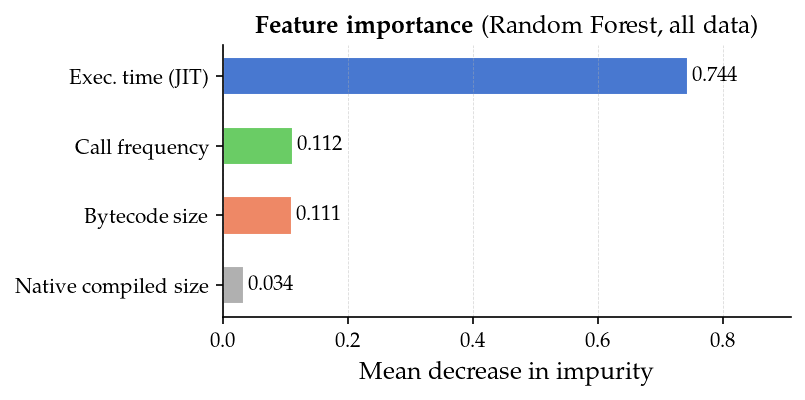

In [44]:
# Figure 3 – feature importance
_rf_full = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
_rf_full.fit(X, y)

_feat_labels = {
    'exec.jit':      r'Exec.\ time (JIT)',
    'freq.jit':      r'Call frequency',
    'size.bytecode': r'Bytecode size',
    'size.static':   r'Native compiled size',
}
_feat_colors = {
    'exec.jit':      '#4878D0',
    'freq.jit':      '#6ACC65',
    'size.bytecode': '#EE8866',
    'size.static':   '#B0B0B0',
}
_pairs = sorted(zip(_FEATURES, _rf_full.feature_importances_), key=lambda p: p[1])

fig, ax = plt.subplots(figsize=(5.5, 2.8))
bars = ax.barh(
    [_feat_labels[f] for f, _ in _pairs],
    [v for _, v in _pairs],
    color=[_feat_colors[f] for f, _ in _pairs],
    edgecolor='white', height=0.55)
for bar, (_, val) in zip(bars, _pairs):
    ax.text(val + 0.006, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel(r'Mean decrease in impurity')
ax.set_title(r'\textbf{Feature importance} (Random Forest, all data)')
ax.set_xlim(0, max(v for _, v in _pairs) * 1.22)
ax.grid(True, axis='x', ls='--', lw=0.4, alpha=0.45)
fig.tight_layout()
fig.savefig(OUT / 'interp-feature-importance.pdf', bbox_inches='tight')
plt.show()

### 4. Prediction API

In [45]:
# ── Fit final model on all available data ─────────────────────────────────────
_interp_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
_interp_model.fit(X, y)


def predict_interp_time(profile_df: pd.DataFrame) -> pd.DataFrame:
    """Estimate exec.interp from a JIT profile + static analysis.

    Input columns required: exec.jit, freq.jit, size.bytecode, size.static
    (all available after a standard JIT run).

    Returns profile_df with 'exec.interp.predicted' added (nanoseconds).
    """
    X_new = np.log1p(profile_df[_FEATURES].fillna(0).values)
    out   = profile_df.copy()
    out['exec.interp.predicted'] = (np.expm1(_interp_model.predict(X_new))
                                    .round().astype('int64'))
    return out


# ── sanity check ──────────────────────────────────────────────────────────────
_sample = data[data['workload'] == workload_names[0]][_FEATURES + ['exec.interp']].head(8)
_result = predict_interp_time(_sample)
(_result[['exec.interp', 'exec.interp.predicted']]
 .assign(rel_err=lambda d: (d['exec.interp.predicted'] - d['exec.interp']).abs()
                            / d['exec.interp'])
 .style
 .format('{:,.0f}', subset=['exec.interp', 'exec.interp.predicted'])
 .format('{:.1%}',  subset=['rel_err'])
 .background_gradient(subset=['rel_err'], cmap='RdYlGn_r', vmin=0, vmax=1))

,exec.interp,exec.interp.predicted,rel_err
759,"2,000,000","3,362,854",68.1%
760,"13,000,000","16,444,569",26.5%
761,"366,000,000","183,536,339",49.9%
762,"264,000,000","160,100,410",39.4%
763,"309,000,000","90,976,836",70.6%
764,"1,000,000","1,679,091",67.9%
765,"32,000,000","54,831,769",71.3%
766,"129,000,000","66,882,033",48.2%
